# Actividad 58 - Clustering jerarquico con datos World Bank

Notebook completo y reproducible del ejercicio.

Objetivos:
- Construir el CSV final con columnas CC, CN, GDP, POP, URB.
- Limpiar filas con valores nulos o invalidos.
- Representar nube 3D.
- Aplicar clustering jerarquico, validar metricas y generar dendrogramas.

## 1. Configuracion del entorno y dependencias

En esta seccion importamos librerias, fijamos semilla global y mostramos versiones para asegurar reproducibilidad.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.3.5
pandas: 2.3.3


## 2. Definicion de parametros del ejercicio

Definimos rutas, columnas requeridas y supuestos operativos del ejercicio.

In [2]:
if Path("API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_35.csv").exists():
    BASE_DIR = Path.cwd()
else:
    BASE_DIR = Path.cwd() / "SistemasAA" / "AprendizajeNoSupervisado" / "Actividad58"

GDP_FILE = BASE_DIR / "API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_35.csv"
POP_FILE = BASE_DIR / "API_SP.POP.TOTL_DS2_en_csv_v2_61.csv"
URB_FILE = BASE_DIR / "API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_249.csv"

OUTPUT_DATASET = BASE_DIR / "actividad58_dataset_paises.csv"
OUTPUT_DATASET_CLUSTERS = BASE_DIR / "actividad58_dataset_con_clusters.csv"
OUTPUT_METRICS = BASE_DIR / "actividad58_metricas_clustering.csv"
OUTPUT_SCATTER = BASE_DIR / "actividad58_scatter3d.png"
OUTPUT_DENDRO_FULL = BASE_DIR / "actividad58_dendrograma_completo.png"
OUTPUT_DENDRO_DIST = BASE_DIR / "actividad58_dendrograma_intermedio_distancia.png"
OUTPUT_DENDRO_K = BASE_DIR / "actividad58_dendrograma_intermedio_k.png"

REQUIRED_OUTPUT_COLS = ["CC", "CN", "GDP", "POP", "URB"]

print("BASE_DIR:", BASE_DIR)
print("Archivos encontrados:")
print("- GDP:", GDP_FILE.exists())
print("- POP:", POP_FILE.exists())
print("- URB:", URB_FILE.exists())

BASE_DIR: c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58
Archivos encontrados:
- GDP: True
- POP: True
- URB: True


## 3. Carga o generacion de datos

Cargamos los tres CSV de World Bank (no se generan datos sinteticos porque hay datos reales).

In [3]:
gdp_raw = pd.read_csv(GDP_FILE, skiprows=4)
pop_raw = pd.read_csv(POP_FILE, skiprows=4)
urb_raw = pd.read_csv(URB_FILE, skiprows=4)

print("Shapes:")
print("GDP:", gdp_raw.shape)
print("POP:", pop_raw.shape)
print("URB:", urb_raw.shape)

display(gdp_raw.head(3))

Shapes:
GDP: (266, 71)
POP: (266, 71)
URB: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21732.858315,23099.940085,23889.045018,24575.660660,25791.043179,26254.742804,26004.495628,27240.802789,27412.755193,27765.653258,30245.706974,31920.239073,31888.508737,32507.084315,35059.273098,35098.797669,35937.594656,37768.566014,38904.999248,34339.939156,33729.511911,35324.072064,34095.647171,35901.645961,35657.287197,35972.859662,36117.535262,37524.914920,39287.059713,38543.907294,28854.597300,35104.786804,41758.895757,46574.357420,50649.301523,NaN,NaN
1,Africa Eastern and Southern,AFE,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1851.172551,1866.163505,1820.062818,1807.249785,1832.163205,1903.826539,1994.831064,2063.257707,2071.874468,2103.976822,2167.022577,2238.454817,2299.255597,2353.972416,2486.091030,2649.498234,2835.845015,3023.755132,3132.535959,3095.108504,3210.348232,3320.033247,3244.664345,3373.823793,3514.322153,3539.815506,3634.441673,3837.726375,3723.216423,3801.413183,3708.094649,4028.376504,4369.191056,4501.601101,4635.788224,NaN,NaN
2,Afghanistan,AFG,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,813.550256,747.688045,926.507941,966.962032,971.633503,1076.087353,1121.834471,1286.949843,1333.747267,1570.698145,1765.538028,1744.060623,1988.429304,2133.241271,2224.490748,2284.075848,2213.181441,2335.795862,2432.276701,2583.485332,2561.981761,2144.166570,2122.995815,2201.722907,NaN,NaN,NaN


## 4. Validacion de esquema y tipos

Comprobamos columnas obligatorias, anos disponibles, duplicados y valores faltantes basicos.

In [4]:
mandatory_cols = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]

def get_year_cols(df):
    return [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]

for name, df_ in [("GDP", gdp_raw), ("POP", pop_raw), ("URB", urb_raw)]:
    missing = [c for c in mandatory_cols if c not in df_.columns]
    year_cols = get_year_cols(df_)
    dups = df_.duplicated(subset=["Country Name", "Country Code"]).sum()
    print(f"[{name}] columnas obligatorias faltantes: {missing}")
    print(f"[{name}] anos detectados: {min(year_cols)} - {max(year_cols)} ({len(year_cols)} anos)")
    print(f"[{name}] duplicados Country Name/Country Code: {dups}")
    print(f"[{name}] nulos en Country Code: {df_['Country Code'].isna().sum()}")
    print("-" * 80)

[GDP] columnas obligatorias faltantes: []
[GDP] anos detectados: 1960 - 2025 (66 anos)
[GDP] duplicados Country Name/Country Code: 0
[GDP] nulos en Country Code: 0
--------------------------------------------------------------------------------
[POP] columnas obligatorias faltantes: []
[POP] anos detectados: 1960 - 2025 (66 anos)
[POP] duplicados Country Name/Country Code: 0
[POP] nulos en Country Code: 0
--------------------------------------------------------------------------------
[URB] columnas obligatorias faltantes: []
[URB] anos detectados: 1960 - 2025 (66 anos)
[URB] duplicados Country Name/Country Code: 0
[URB] nulos en Country Code: 0
--------------------------------------------------------------------------------


## 5. Limpieza y preprocesamiento

Se toma el ano mas reciente con datos validos conjuntos para GDP per capita, POP total y porcentaje urbano.

Despues se construye el dataset final con:
- GDP = GDP per capita * POP
- URB = POP * URB_PCT / 100

In [6]:
def clean_merge_for_year(gdp_df, pop_df, urb_df, year):
    cols = ["Country Name", "Country Code", year]
    g = gdp_df[cols].rename(columns={year: "GDP_PC"})
    p = pop_df[cols].rename(columns={year: "POP"})
    u = urb_df[cols].rename(columns={year: "URB_PCT"})

    merged = (
        g.merge(p, on=["Country Name", "Country Code"], how="inner")
         .merge(u, on=["Country Name", "Country Code"], how="inner")
         .rename(columns={"Country Name": "CN", "Country Code": "CC"})
    )

    for col in ["GDP_PC", "POP", "URB_PCT"]:
        merged[col] = pd.to_numeric(merged[col], errors="coerce")

    merged = merged.replace([np.inf, -np.inf], np.nan).dropna(subset=["GDP_PC", "POP", "URB_PCT"])
    merged = merged[(merged["GDP_PC"] > 0) & (merged["POP"] > 0) & (merged["URB_PCT"].between(0, 100))].copy()

    # Filtrado de paises para evitar agregados regionales/supranacionales
    try:
        import pycountry
        valid_codes = {c.alpha_3 for c in pycountry.countries if hasattr(c, "alpha_3")}
        merged = merged[merged["CC"].isin(valid_codes)].copy()
    except Exception:
        merged = merged[
            merged["CC"].str.fullmatch(r"[A-Z]{3}", na=False)
            & ~merged["CN"].str.contains(
                "income|world|union|OECD|IDA|IBRD|states|Europe|Asia|Africa|America",
                case=False,
                na=False,
            )
        ].copy()

    merged["GDP"] = merged["GDP_PC"] * merged["POP"]
    merged["URB"] = merged["POP"] * merged["URB_PCT"] / 100.0

    return merged[["CC", "CN", "GDP", "POP", "URB", "GDP_PC", "URB_PCT"]]


years_common = sorted(set(get_year_cols(gdp_raw)) & set(get_year_cols(pop_raw)) & set(get_year_cols(urb_raw)), reverse=True)

selected_year = None
work_df = pd.DataFrame()
for y in years_common:
    tmp = clean_merge_for_year(gdp_raw, pop_raw, urb_raw, y)
    if len(tmp) > len(work_df):
        selected_year = y
        work_df = tmp
    if len(tmp) >= 150:
        selected_year = y
        work_df = tmp
        break

final_df = work_df[REQUIRED_OUTPUT_COLS].copy().dropna().reset_index(drop=True)

print("Ano seleccionado:", selected_year)
print("Filas validas:", len(final_df))
print("Columnas finales:", final_df.columns.tolist())

# Export requerido por el enunciado
final_df.to_csv(OUTPUT_DATASET, index=False)
print("CSV final guardado en:", OUTPUT_DATASET)

display(final_df.head(10))

Ano seleccionado: 2024
Filas validas: 192
Columnas finales: ['CC', 'CN', 'GDP', 'POP', 'URB']
CSV final guardado en: c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dataset_paises.csv


,CC,CN,GDP,POP,URB
0,ABW,Aruba,5.469871e+09,107995.0,6.673113e+04
1,AGO,Angola,3.833521e+11,37885849.0,2.676830e+07
2,ALB,Albania,6.347330e+10,2377128.0,1.391722e+06
3,AND,Andorra,6.140391e+09,81938.0,7.283059e+04
4,ARE,United Arab Emirates,8.704386e+11,10986400.0,9.428211e+06
5,ARG,Argentina,1.390589e+12,45696159.0,4.216578e+07
6,ARM,Armenia,6.923412e+10,3033500.0,1.996388e+06
7,ATG,Antigua and Barbuda,3.130690e+09,93772.0,2.287164e+04
8,AUS,Australia,1.961194e+12,27196812.0,2.382499e+07
9,AUT,Austria,6.783579e+11,9177982.0,6.375560e+06


## 6. Analisis exploratorio con metricas y graficos

Mostramos estadisticos basicos, correlaciones y visualizaciones principales.

,CC,CN,GDP,POP,URB
count,192,192,1.920000e+02,1.920000e+02,1.920000e+02
unique,192,192,NaN,NaN,NaN
top,ABW,Aruba,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN
mean,NaN,NaN,2.100238e+12,9.993438e+07,5.453302e+07
std,NaN,NaN,8.739566e+12,3.745524e+08,2.014904e+08
min,NaN,NaN,1.693249e+08,1.194700e+04,1.194700e+04
25%,NaN,NaN,3.734769e+10,2.068679e+06,1.174994e+06
50%,NaN,NaN,1.344398e+11,9.346609e+06,4.888272e+06
75%,NaN,NaN,7.055215e+11,3.536463e+07,1.885772e+07


Correlacion:


,GDP,POP,URB
GDP,1.000000,0.791825,0.898079
POP,0.791825,1.000000,0.970604
URB,0.898079,0.970604,1.000000


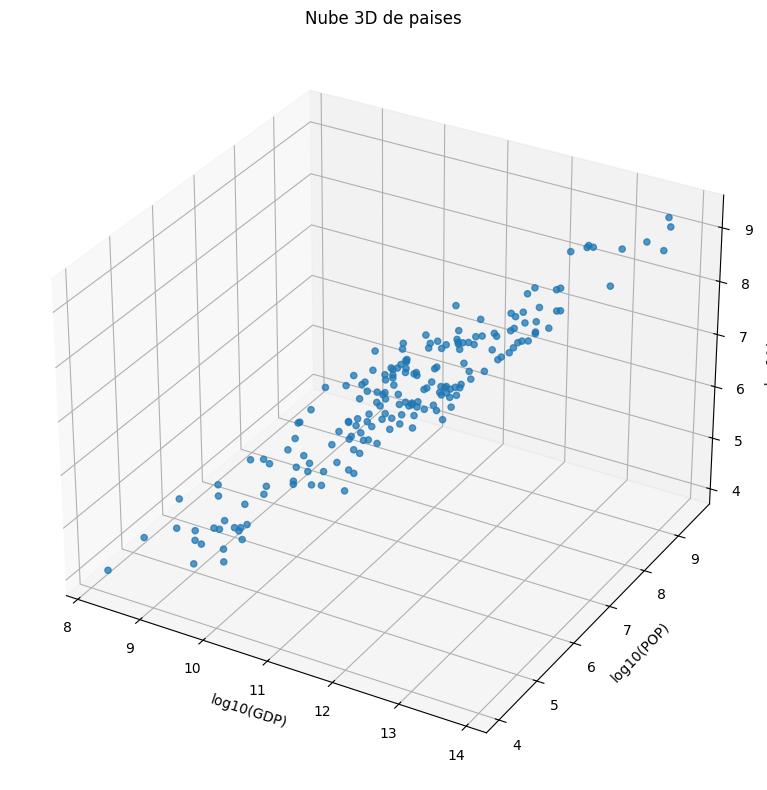

In [7]:
display(final_df.describe(include="all"))

corr = final_df[["GDP", "POP", "URB"]].corr()
print("Correlacion:")
display(corr)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

x = np.log10(final_df["GDP"])
y = np.log10(final_df["POP"])
z = np.log10(final_df["URB"])

ax.scatter(x, y, z, alpha=0.75)
if len(final_df) <= 80:
    for _, row in final_df.iterrows():
        ax.text(np.log10(row["GDP"]), np.log10(row["POP"]), np.log10(row["URB"]), row["CC"], fontsize=7)

ax.set_xlabel("log10(GDP)")
ax.set_ylabel("log10(POP)")
ax.set_zlabel("log10(URB)")
ax.set_title("Nube 3D de paises")
plt.tight_layout()
plt.show()

## 7. Ingenieria de caracteristicas

Aplicamos transformaciones logaritmicas y estandarizacion para clustering jerarquico.

In [8]:
feature_cols = ["GDP", "POP", "URB"]

X_raw = final_df[feature_cols].copy()
X_log = np.log1p(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

feature_df = pd.DataFrame(X_scaled, columns=[f"{c}_z" for c in feature_cols])
display(feature_df.head())
print("Shape features:", X_scaled.shape)

,GDP_z,POP_z,URB_z
0,-1.311225,-1.775498,-1.730656
1,0.414686,0.669576,0.752411
2,-0.315663,-0.485605,-0.472359
3,-1.264263,-1.890704,-1.694425
4,0.747726,0.153077,0.320148


Shape features: (192, 3)


## 8. Particion de datos (train/valid/test)

Aunque es aprendizaje no supervisado, hacemos particion reproducible para separar ajuste y comprobacion de estabilidad.

In [9]:
# Estratificacion aproximada usando cuantiles de log(GDP)
strata = pd.qcut(np.log1p(final_df["GDP"]), q=5, labels=False, duplicates="drop")

idx_all = np.arange(len(final_df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.3, random_state=42, stratify=strata)
strata_temp = strata.iloc[idx_temp]
idx_valid, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=strata_temp)

X_train = X_scaled[idx_train]
X_valid = X_scaled[idx_valid]
X_test = X_scaled[idx_test]

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)

Train: (134, 3) Valid: (29, 3) Test: (29, 3)


## 9. Entrenamiento del modelo base

Entrenamos un modelo jerarquico base con criterio Ward y k inicial.

In [10]:
base_k = 3
base_linkage = "ward"

base_model = AgglomerativeClustering(n_clusters=base_k, linkage=base_linkage)
base_labels_train = base_model.fit_predict(X_train)

print("Modelo base entrenado con linkage=ward, k=3")
print("Clusters train:", np.unique(base_labels_train))

Modelo base entrenado con linkage=ward, k=3
Clusters train: [0 1 2]


## 10. Evaluacion con metricas y matriz de confusion

Como no hay etiquetas reales, usamos metricas internas (Silhouette, Calinski-Harabasz y Davies-Bouldin).

En lugar de matriz de confusion clasica, mostramos una matriz de contingencia entre dos soluciones de clustering para inspeccionar consistencia.

In [11]:
def clustering_metrics(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
    }

base_metrics = clustering_metrics(X_train, base_labels_train)
print("Metricas modelo base:", base_metrics)

alt_model = AgglomerativeClustering(n_clusters=3, linkage="complete")
alt_labels_train = alt_model.fit_predict(X_train)
contingency = pd.crosstab(pd.Series(base_labels_train, name="ward"), pd.Series(alt_labels_train, name="complete"))

print("Matriz de contingencia ward vs complete (anologa a confusion):")
display(contingency)

Metricas modelo base: {'silhouette': 0.4706474527883408, 'calinski_harabasz': 175.35502863240202, 'davies_bouldin': 0.5698070162419511}
Matriz de contingencia ward vs complete (anologa a confusion):


complete,0,1,2
ward,,,
0,16,0,78
1,0,26,0
2,14,0,0


## 11. Ajuste de hiperparametros

Probamos combinaciones de linkage y numero de clusters en train para optimizar de forma sistematica.

In [12]:
search_rows = []
for link in ["single", "complete", "ward"]:
    for k in range(2, 11):
        model = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = model.fit_predict(X_train)
        m = clustering_metrics(X_train, labels)
        search_rows.append({"linkage": link, "k": k, **m})

search_df = pd.DataFrame(search_rows)
search_df = search_df.sort_values(
    by=["silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(search_df.head(15))

,linkage,k,silhouette,calinski_harabasz,davies_bouldin
0,complete,2,0.511766,149.608303,0.637590
1,complete,3,0.499799,229.917049,0.628126
2,single,2,0.494768,37.955530,0.422933
3,ward,3,0.470647,175.355029,0.569807
4,ward,2,0.454361,107.954923,0.649384
5,complete,4,0.435612,205.796152,0.638998
6,complete,9,0.420236,284.741364,0.686922
7,complete,10,0.417168,277.654269,0.700570
8,ward,8,0.408202,249.362442,0.712099
9,complete,5,0.406121,208.601428,0.598863


## 12. Comparacion de modelos y seleccion final

Seleccionamos la mejor configuracion segun el ranking de metricas y entrenamos el modelo final sobre todo el dataset.

In [ ]:
best_row = search_df.iloc[0]
best_linkage = best_row["linkage"]
best_k = int(best_row["k"])

final_model = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
final_labels = final_model.fit_predict(X_scaled)

final_with_clusters = final_df.copy()
final_with_clusters["cluster"] = final_labels

print("Mejor configuracion:", {"linkage": best_linkage, "k": best_k})
print("Metricas mejor configuracion:")
print(best_row.to_dict())
display(final_with_clusters.head(10))

Mejor configuracion: {'linkage': 'complete', 'k': 2}
Metricas mejor configuracion:
{'linkage': 'complete', 'k': 2, 'silhouette': 0.5117658153942188, 'calinski_harabasz': 149.60830283967874, 'davies_bouldin': 0.6375903317121988}


,CC,CN,GDP,POP,URB,cluster
0,ABW,Aruba,5.469871e+09,107995.0,6.673113e+04,0
1,AGO,Angola,3.833521e+11,37885849.0,2.676830e+07,1
2,ALB,Albania,6.347330e+10,2377128.0,1.391722e+06,0
3,AND,Andorra,6.140391e+09,81938.0,7.283059e+04,0
4,ARE,United Arab Emirates,8.704386e+11,10986400.0,9.428211e+06,1
5,ARG,Argentina,1.390589e+12,45696159.0,4.216578e+07,1
6,ARM,Armenia,6.923412e+10,3033500.0,1.996388e+06,0
7,ATG,Antigua and Barbuda,3.130690e+09,93772.0,2.287164e+04,0
8,AUS,Australia,1.961194e+12,27196812.0,2.382499e+07,1
9,AUT,Austria,6.783579e+11,9177982.0,6.375560e+06,1


## 13. Guardado de artefactos y resultados

Exportamos solo artefactos tabulares (CSV) para trazabilidad.

Las graficas se muestran inline en el notebook y no se descargan a disco.

In [ ]:
# Guardado de artefactos tabulares (sin guardar graficas)
final_df.to_csv(OUTPUT_DATASET, index=False)
final_with_clusters.to_csv(OUTPUT_DATASET_CLUSTERS, index=False)
search_df.to_csv(OUTPUT_METRICS, index=False)

print("CSV guardados:")
print(OUTPUT_DATASET)
print(OUTPUT_DATASET_CLUSTERS)
print(OUTPUT_METRICS)
print("Graficas: solo visualizacion inline (no se descargan).")

Guardados:
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dataset_paises.csv
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dataset_con_clusters.csv
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_metricas_clustering.csv
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_scatter3d.png
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dendrograma_completo.png
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dendrograma_intermedio_distancia.png
c:\Users\usuario\Documents\BigData\SistemasAA\AprendizajeNoSupervisado\Actividad58\actividad58_dendrograma_intermedio_k.png


## 14. Celdas de ejecucion automatica y pruebas basicas

Incluimos asserts para validar forma, columnas y ausencia de nulos en salidas criticas.

In [ ]:
assert all(c in final_df.columns for c in REQUIRED_OUTPUT_COLS), "Faltan columnas obligatorias"
assert final_df[REQUIRED_OUTPUT_COLS].isna().sum().sum() == 0, "Hay nulos en dataset final"
assert len(final_df) > 0, "Dataset final vacio"
assert len(search_df) >= 3, "Muy pocas combinaciones evaluadas"
assert Path(OUTPUT_DATASET).exists(), "No se guardo el CSV final"
assert Path(OUTPUT_DATASET_CLUSTERS).exists(), "No se guardo el CSV con clusters"
assert Path(OUTPUT_METRICS).exists(), "No se guardo el CSV de metricas"

print("Validaciones OK")
print(f"Ano usado: {selected_year}")
print(f"Paises validos: {len(final_df)}")
print(f"Mejor linkage: {best_linkage} | k: {best_k}")
print("Graficas en notebook: inline y sin descarga")

Validaciones OK
Ano usado: 2024
Paises validos: 192
Mejor linkage: complete | k: 2


## 15. Graficas inline (sin descargar)

Estas graficas se muestran directamente en el notebook y no se guardan a disco.

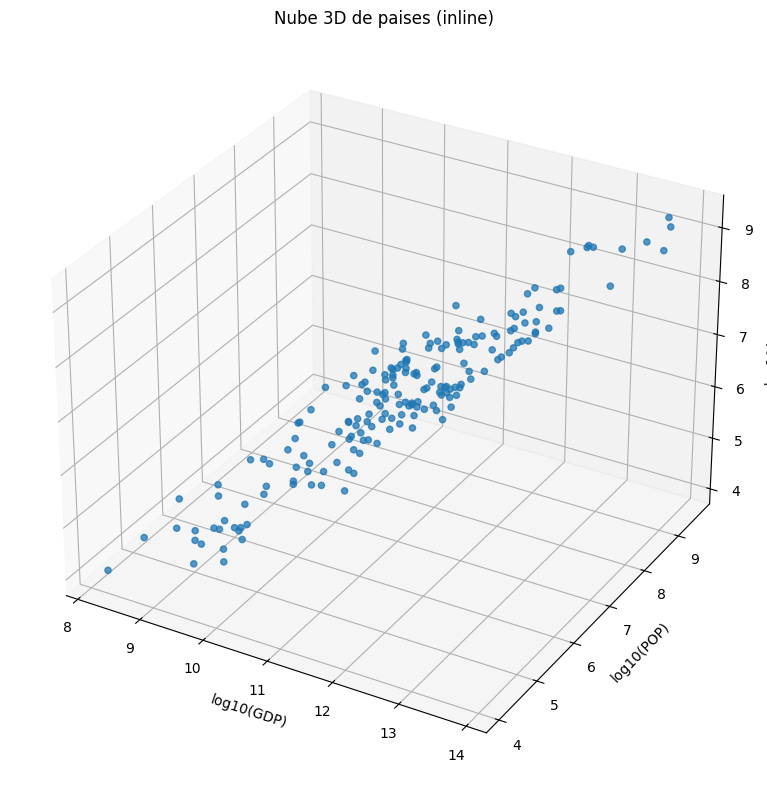

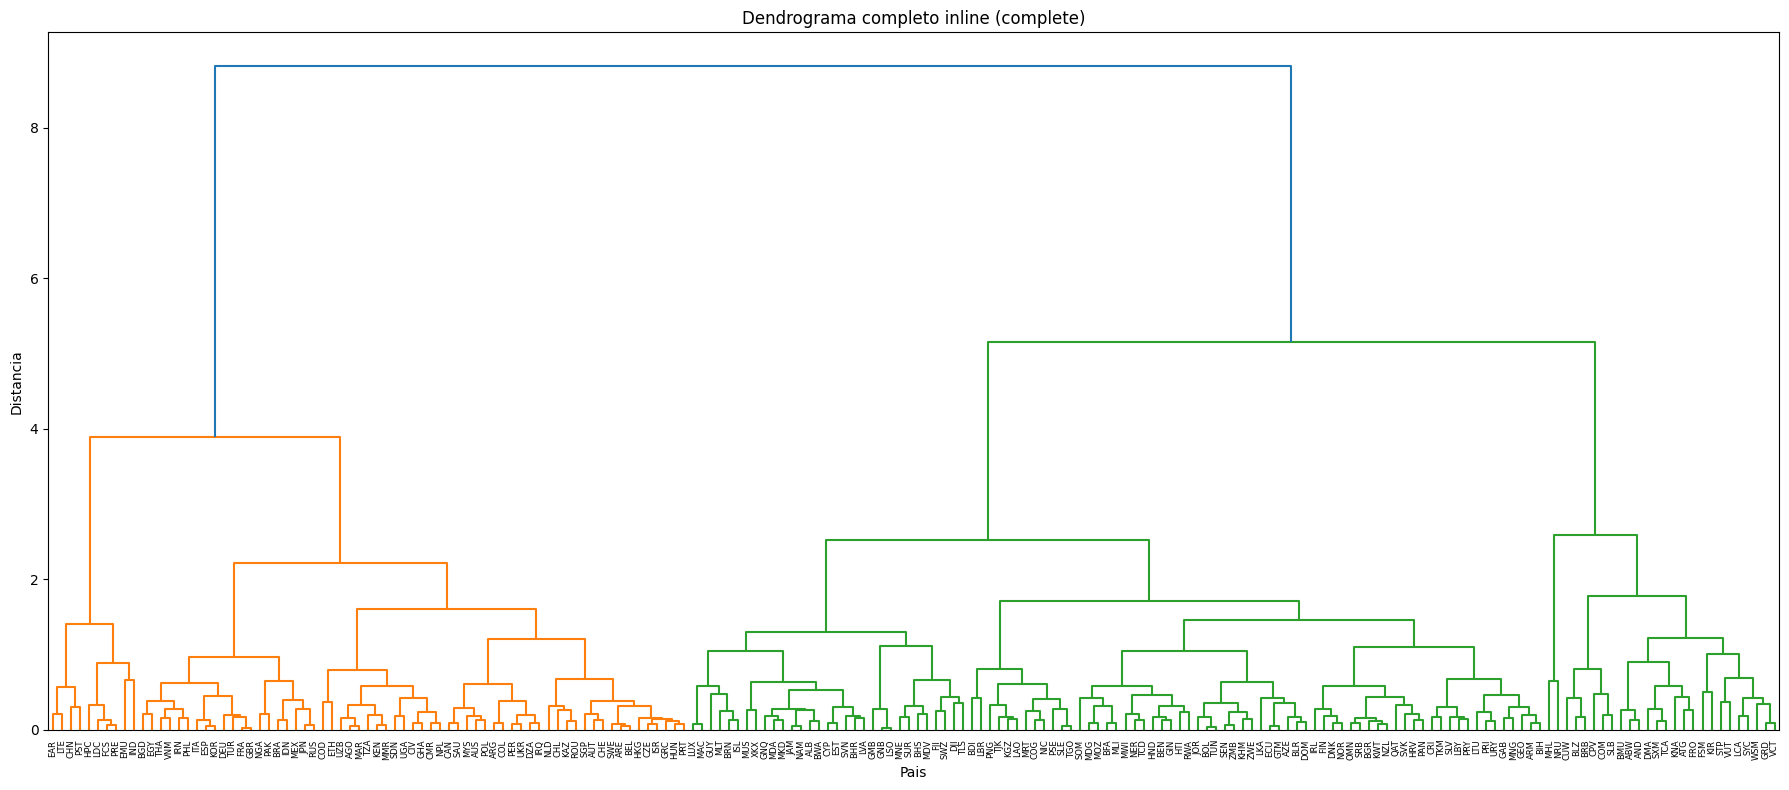

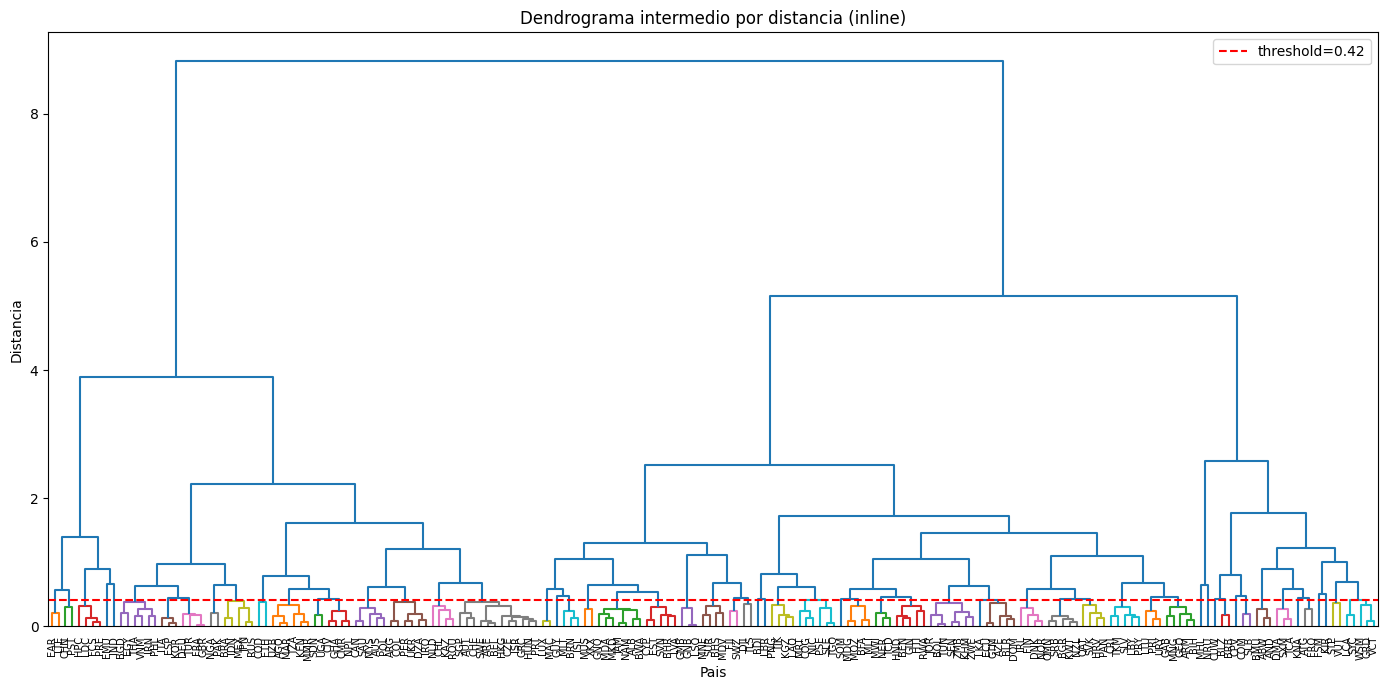

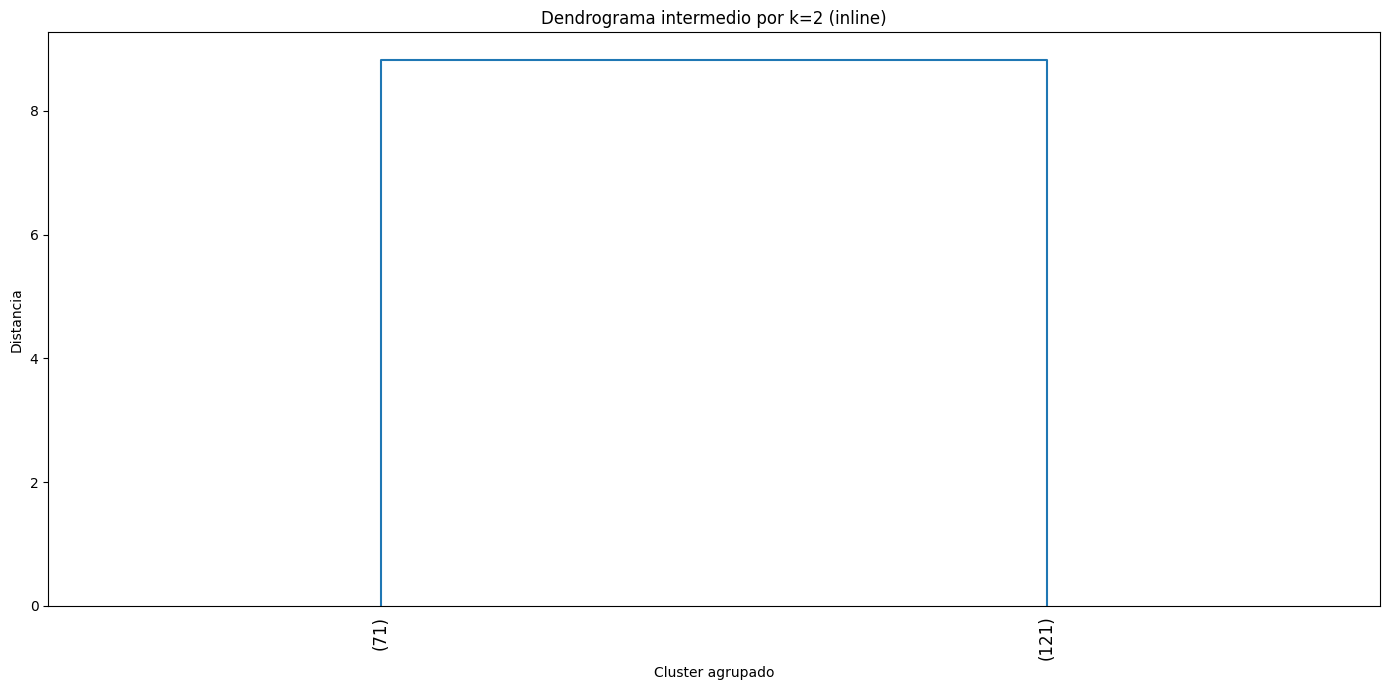

In [16]:
# 1) Scatter 3D inline
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(np.log10(final_df["GDP"]), np.log10(final_df["POP"]), np.log10(final_df["URB"]), alpha=0.75)
ax.set_xlabel("log10(GDP)")
ax.set_ylabel("log10(POP)")
ax.set_zlabel("log10(URB)")
ax.set_title("Nube 3D de paises (inline)")
plt.tight_layout()
plt.show()

# 2) Dendrograma completo inline
Z_inline = linkage(X_scaled, method=best_linkage, metric="euclidean")
fig = plt.figure(figsize=(18, 8))
dendrogram(Z_inline, labels=final_df["CC"].tolist(), leaf_rotation=90, leaf_font_size=6)
plt.title(f"Dendrograma completo inline ({best_linkage})")
plt.xlabel("Pais")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# 3) Dendrograma intermedio por distancia inline
dist_threshold_inline = float(np.percentile(Z_inline[:, 2], 70))
fig = plt.figure(figsize=(14, 7))
dendrogram(
    Z_inline,
    labels=final_df["CC"].tolist(),
    color_threshold=dist_threshold_inline,
    leaf_rotation=90,
    leaf_font_size=7,
)
plt.axhline(y=dist_threshold_inline, c="red", ls="--", label=f"threshold={dist_threshold_inline:.2f}")
plt.legend()
plt.title("Dendrograma intermedio por distancia (inline)")
plt.xlabel("Pais")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# 4) Dendrograma intermedio por numero de clusters inline
fig = plt.figure(figsize=(14, 7))
dendrogram(
    Z_inline,
    truncate_mode="lastp",
    p=best_k,
    show_leaf_counts=True,
    leaf_rotation=90,
)
plt.title(f"Dendrograma intermedio por k={best_k} (inline)")
plt.xlabel("Cluster agrupado")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

## 16. Revision del enunciado y graficas extra

Comprobacion rapida de que se cumple lo pedido:

1. CSV final con columnas CC, CN, GDP, POP, URB y sin nulos.
2. Nube de puntos 3D.
3. Clustering jerarquico con validacion por metricas internas.
4. Dendrograma completo.
5. Dendrograma intermedio por distancia y por numero de clusters.

Graficas extra añadidas para interpretar mejor el resultado:
- Evolucion de Silhouette segun k y linkage.
- Tamano de cada cluster final.

In [ ]:
# Checklist del enunciado
checklist = {
    "CSV columnas exactas": list(final_df.columns) == REQUIRED_OUTPUT_COLS,
    "CSV sin nulos": final_df[REQUIRED_OUTPUT_COLS].isna().sum().sum() == 0,
    "Dendrograma completo generado inline": True,
    "Dendrograma intermedio (distancia) generado inline": True,
    "Dendrograma intermedio (k) generado inline": True,
    "Metricas de validacion calculadas": {"silhouette", "calinski_harabasz", "davies_bouldin"}.issubset(set(search_df.columns)),
}

display(pd.DataFrame({"requisito": checklist.keys(), "cumple": checklist.values()}))

# Grafica extra 1: Silhouette por k y linkage
fig, ax = plt.subplots(figsize=(10, 5))
for link in sorted(search_df["linkage"].unique()):
    sub = search_df[search_df["linkage"] == link].sort_values("k")
    ax.plot(sub["k"], sub["silhouette"], marker="o", label=link)
ax.set_title("Silhouette segun k y criterio de enlace")
ax.set_xlabel("Numero de clusters (k)")
ax.set_ylabel("Silhouette")
ax.grid(alpha=0.3)
ax.legend(title="linkage")
plt.tight_layout()
plt.show()

# Grafica extra 2: tamano de clusters finales
cluster_sizes = final_with_clusters["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
ax.set_title("Tamano de clusters finales")
ax.set_xlabel("Cluster")
ax.set_ylabel("Numero de paises")
for i, v in enumerate(cluster_sizes.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()